In [1]:
from google.colab import drive
import os
drive.mount('/content/drive')
project_path = '/content/drive/MyDrive/Customer_Churn_Thesis/notebooks'
os.chdir(project_path)

Mounted at /content/drive


In [2]:
!pip install imbalanced-learn xgboost lightgbm -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sns.set_theme(style="whitegrid")
os.makedirs('../results/tables', exist_ok=True)
os.makedirs('../results/figures', exist_ok=True)

In [3]:
df = pd.read_csv('../data/raw/Churn_Modelling.csv')

df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print(f"Data Ready. Train Shape: {X_train_bal.shape}, Test Shape: {X_test_scaled.shape}")

Data Ready. Train Shape: (12740, 11), Test Shape: (2000, 11)


In [4]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(verbose=-1, random_state=42)
}

results = []

print(f"Running baseline comparison for {len(models)} models")

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        "Model": name,
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

    print(f" -> {name} finished.")

results_df = pd.DataFrame(results).sort_values(by='Recall', ascending=False)
print("\n Final Leaderboard")
print(results_df)

results_df.to_csv('../results/tables/Phase1_Comparison_results.csv', index=False)

Running baseline comparison for 5 models
 -> Logistic Regression finished.
 -> Decision Tree finished.
 -> Random Forest finished.
 -> XGBoost finished.
 -> LightGBM finished.

 Final Leaderboard
                 Model    Recall  F1-Score  Precision  Accuracy   ROC-AUC
0  Logistic Regression  0.697789  0.499560   0.389041    0.7155  0.776875
2        Random Forest  0.609337  0.610837   0.612346    0.8420  0.847307
3              XGBoost  0.562654  0.606623   0.658046    0.8515  0.838021
4             LightGBM  0.560197  0.614555   0.680597    0.8570  0.857363
1        Decision Tree  0.513514  0.470721   0.434511    0.7650  0.671383


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


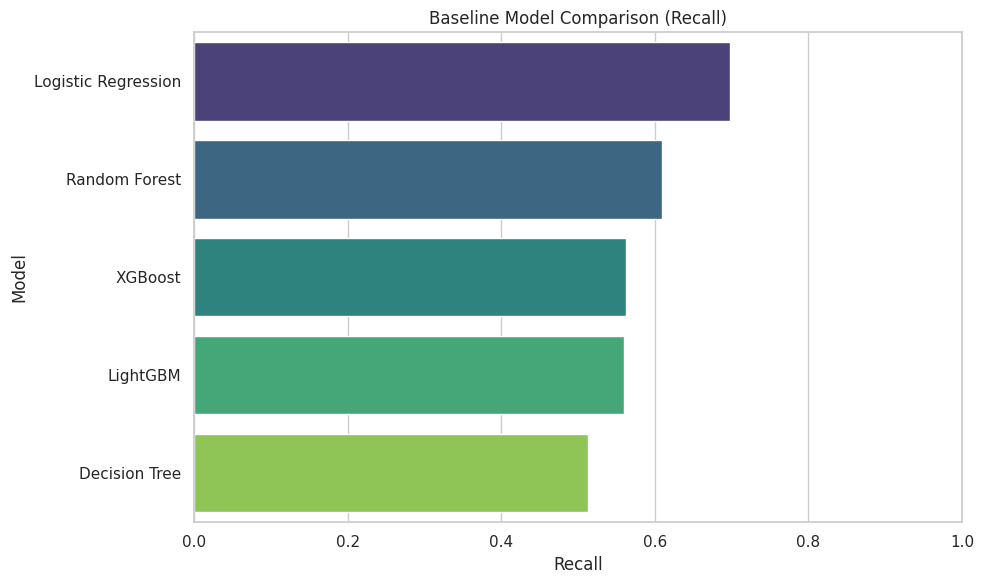

In [5]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Recall', y='Model', data=results_df, hue='Model', palette='viridis', legend=False)
plt.title("Baseline Model Comparison (Recall)")
plt.xlim(0, 1)

plt.tight_layout()
plt.savefig('../results/figures/Phase1_Comparison_model_recall_comparison.png', dpi=300)
plt.show()